In [3]:
import pandas as pd

df = pd.read_csv("C:/Users/Sambhrama/Downloads/final_aviation_ml_dataset_deduplicated.csv")
print(df.shape)
print(df.head())

print(df['hfacs_label'].value_counts())



(17993, 4)
            ev_id  event_date  \
0  20080107X00026  2008-01-01   
1  20080107X00027  2008-01-03   
2  20080109X00036  2008-01-01   
3  20080114X00044  2008-01-06   
4  20080115X00046  2008-01-03   

                                         report_text   hfacs_label  
0  The pilots were attending a fly-in at the airp...    Unsafe Act  
1  After an uneventful landing at night, the comm...  Precondition  
2  The private pilot was conducting a touch-and-g...  Precondition  
3  According to the certified flight instructor (...    Unsafe Act  
4  While on short final approach the pilot reduce...    Unsafe Act  
Unsafe Act            15358
Precondition           2376
Unsafe Supervision      259
Name: hfacs_label, dtype: int64


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['report_text'].apply(clean_text)

print(df[['report_text', 'clean_text']].head())


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sambhrama\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                         report_text  \
0  The pilots were attending a fly-in at the airp...   
1  After an uneventful landing at night, the comm...   
2  The private pilot was conducting a touch-and-g...   
3  According to the certified flight instructor (...   
4  While on short final approach the pilot reduce...   

                                          clean_text  
0  pilot attending flyin airport one pilot lowwin...  
1  uneventful landing night commercial rated pilo...  
2  private pilot conducting touchandgo tailwheele...  
3  according certified flight instructor cfi depa...  
4  short final approach pilot reduced engine powe...  


In [6]:
print(df.columns)


Index(['ev_id', 'event_date', 'report_text', 'hfacs_label', 'clean_text'], dtype='object')


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,   # limit vocabulary size (important)
    ngram_range=(1, 2)   # use unigrams + bigrams
)

# Convert text to numeric features
X = vectorizer.fit_transform(df['clean_text'])

# Target labels
y = df['hfacs_label']

print("TF-IDF feature matrix shape:", X.shape)
print("Target shape:", y.shape)


TF-IDF feature matrix shape: (17993, 5000)
Target shape: (17993,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                # TF-IDF features
    y,                # labels
    test_size=0.2,    # 20% test data
    random_state=42,  # reproducibility
    stratify=y        # keep class distribution same
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (14394, 5000)
Testing set shape: (3599, 5000)


In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=15,     # K = 5 (standard choice)
    metric='cosine',
    weights='distance'# cosine similarity is best for TF-IDF
)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(y_pred[:10])

['Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Precondition'
 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act' 'Unsafe Act']


In [17]:
y_test.value_counts(normalize=True)


Unsafe Act            0.853570
Precondition          0.131981
Unsafe Supervision    0.014448
Name: hfacs_label, dtype: float64

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


                    precision    recall  f1-score   support

      Precondition       0.61      0.30      0.41       475
        Unsafe Act       0.89      0.97      0.93      3072
Unsafe Supervision       0.33      0.02      0.04        52

          accuracy                           0.87      3599
         macro avg       0.61      0.43      0.46      3599
      weighted avg       0.84      0.87      0.84      3599



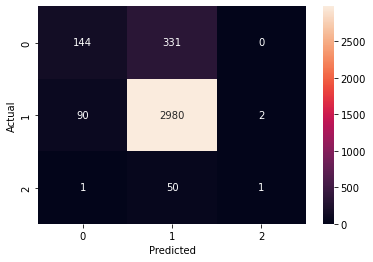

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [20]:
#to test
test_texts = [
    "The pilot was fatigued after long duty hours and visibility was low.",
    "The operator failed to provide adequate training to the pilot.",
    "The pilot ignored standard procedures during approach."
]

clean_texts = [clean_text(t) for t in test_texts]
vectors = vectorizer.transform(clean_texts)
predictions = knn.predict(vectors)

for t, p in zip(test_texts, predictions):
    print("TEXT:", t)
    print("PREDICTED:", p)
    print("-----")


TEXT: The pilot was fatigued after long duty hours and visibility was low.
PREDICTED: Unsafe Act
-----
TEXT: The operator failed to provide adequate training to the pilot.
PREDICTED: Unsafe Act
-----
TEXT: The pilot ignored standard procedures during approach.
PREDICTED: Unsafe Act
-----
